In [ ]:
import os

base_dir = r'C:\Users\ykks\Desktop\zuoye\25 spring\542\project\CUB_200_2011'

def print_directory_tree(root_dir):
    for root, dirs, files in os.walk(root_dir):
        level = root.replace(root_dir, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f"{subindent}{f}")

print("dataset structure:")
print_directory_tree(base_dir)


数据集目录结构：
CUB_200_2011/
    attributes.txt
    CUB_200_2011/
        bounding_boxes.txt
        classes.txt
        images.txt
        image_class_labels.txt
        README
        train_test_split.txt
        attributes/
            certainties.txt
            class_attribute_labels_continuous.txt
            image_attribute_labels.txt
        images/
            001.Black_footed_Albatross/
                Black_Footed_Albatross_0001_796111.jpg
                Black_Footed_Albatross_0002_55.jpg
                Black_Footed_Albatross_0003_796136.jpg
                Black_Footed_Albatross_0005_796090.jpg
                Black_Footed_Albatross_0006_796065.jpg
                Black_Footed_Albatross_0007_796138.jpg
                Black_Footed_Albatross_0008_796083.jpg
                Black_Footed_Albatross_0009_34.jpg
                Black_Footed_Albatross_0010_796097.jpg
                Black_Footed_Albatross_0014_89.jpg
                Black_Footed_Albatross_0016_796067.jpg
             

✅ Analyzing dataset at: C:\Users\ykks\Desktop\zuoye\25 spring\542\project\CUB_200_2011\CUB_200_2011\images

📊 Class distribution:
001.Black_footed_Albatross: 60 images
002.Laysan_Albatross: 60 images
003.Sooty_Albatross: 58 images
004.Groove_billed_Ani: 60 images
005.Crested_Auklet: 44 images
006.Least_Auklet: 41 images
007.Parakeet_Auklet: 53 images
008.Rhinoceros_Auklet: 48 images
009.Brewer_Blackbird: 59 images
010.Red_winged_Blackbird: 60 images
011.Rusty_Blackbird: 60 images
012.Yellow_headed_Blackbird: 56 images
013.Bobolink: 60 images
014.Indigo_Bunting: 60 images
015.Lazuli_Bunting: 58 images
016.Painted_Bunting: 58 images
017.Cardinal: 57 images
018.Spotted_Catbird: 45 images
019.Gray_Catbird: 59 images
020.Yellow_breasted_Chat: 59 images
021.Eastern_Towhee: 60 images
022.Chuck_will_Widow: 56 images
023.Brandt_Cormorant: 59 images
024.Red_faced_Cormorant: 52 images
025.Pelagic_Cormorant: 60 images
026.Bronzed_Cowbird: 60 images
027.Shiny_Cowbird: 60 images
028.Brown_Creeper: 5

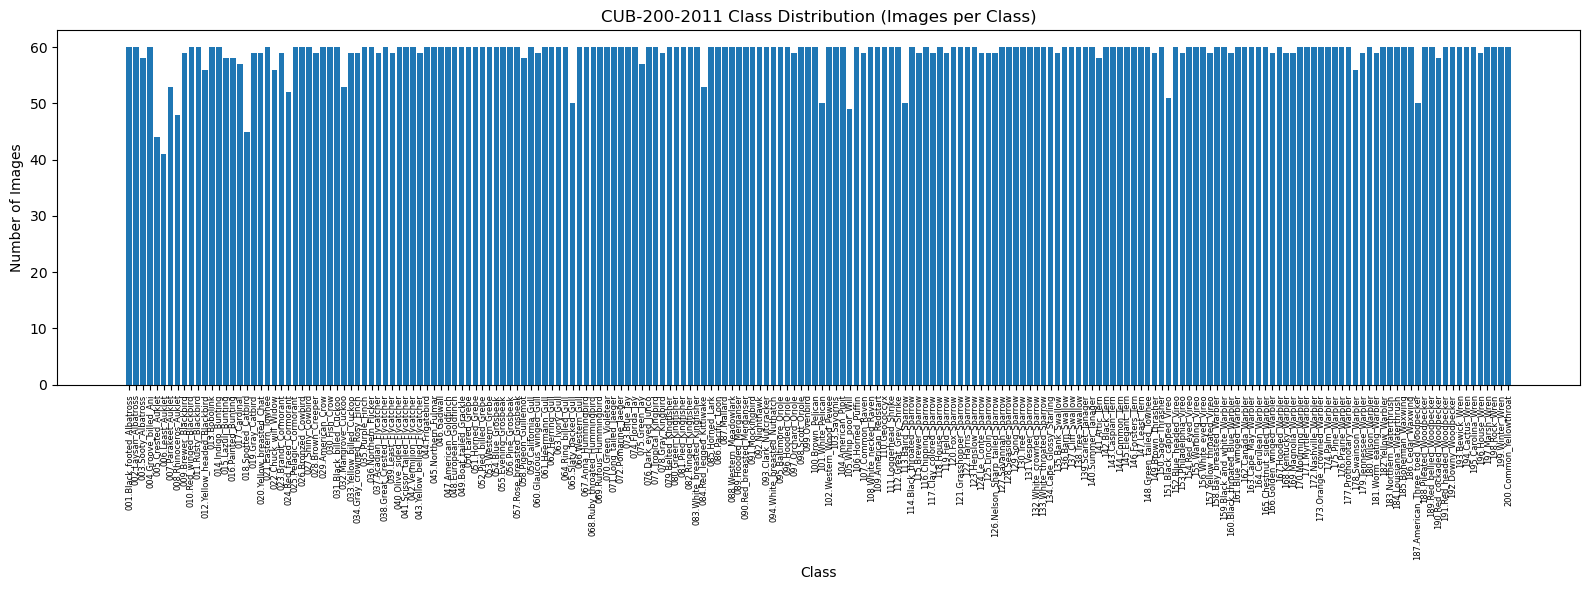


📐 Average image size: 467.89 x 386.03

🎞️ Displaying 9 random image samples:


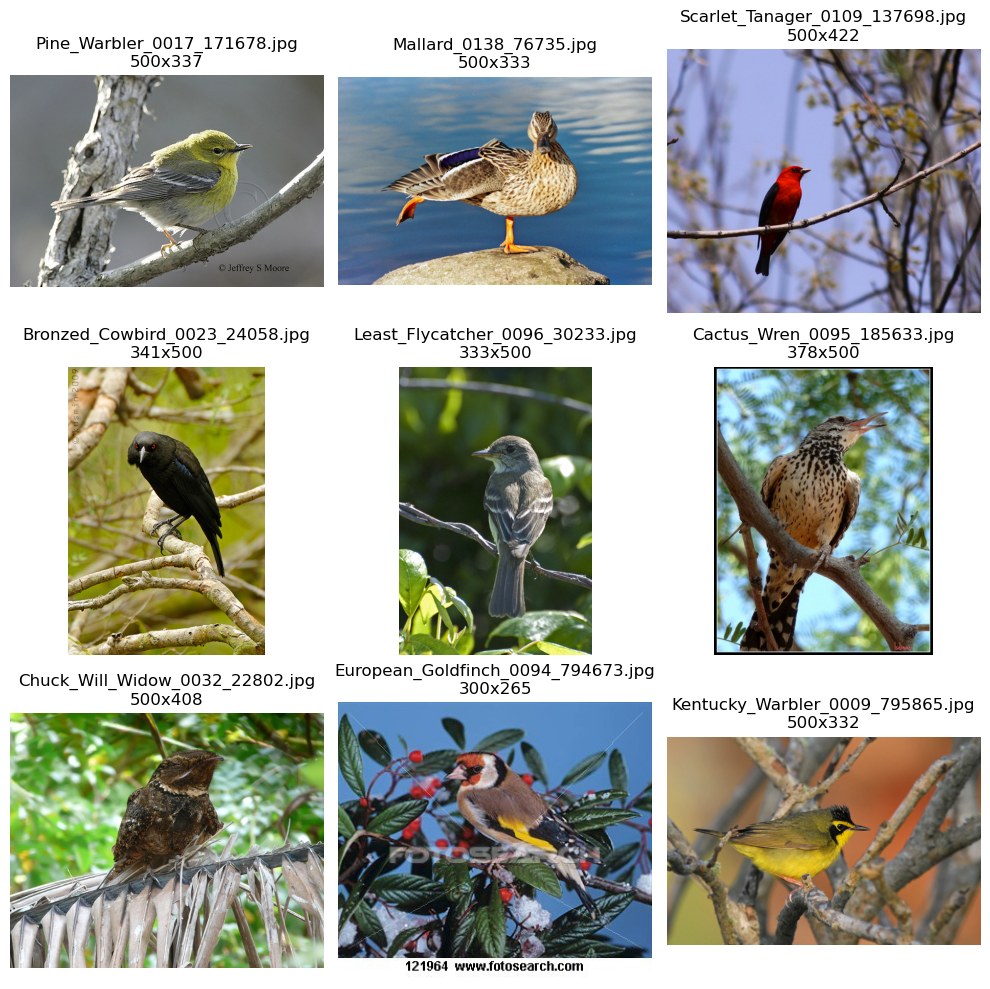

In [1]:
import os
from collections import defaultdict
from PIL import Image
import matplotlib.pyplot as plt
import random

# Define supported image extensions
IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

def get_dataset_info(root_dir):
    """
    Traverse the given directory, count the number of images per class,
    and collect image size statistics.

    Args:
        root_dir: The dataset root directory (e.g., the 'images' folder)

    Returns:
        class_distribution: dict mapping class names to image counts
        image_sizes: list of all image sizes as (width, height)
    """
    class_distribution = {}
    image_sizes = []
    
    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if os.path.isdir(class_path):
            images = [f for f in os.listdir(class_path) if f.lower().endswith(IMAGE_EXTENSIONS)]
            class_distribution[class_name] = len(images)
            for img_file in images:
                img_path = os.path.join(class_path, img_file)
                try:
                    with Image.open(img_path) as img:
                        image_sizes.append(img.size)
                except Exception as e:
                    print(f"Failed to read image {img_path}: {e}")
    return class_distribution, image_sizes

def plot_class_distribution(class_distribution, title):
    """
    Plot a bar chart of image counts per class.
    """
    classes = list(class_distribution.keys())
    counts = list(class_distribution.values())
    plt.figure(figsize=(16, 6))
    plt.bar(classes, counts)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=90, fontsize=6)
    plt.tight_layout()
    plt.show()

def display_random_images(root_dir, num_images=9):
    """
    Randomly display a number of image samples.
    """
    image_paths = []
    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if os.path.isdir(class_path):
            for f in os.listdir(class_path):
                if f.lower().endswith(IMAGE_EXTENSIONS):
                    image_paths.append(os.path.join(class_path, f))
    selected = random.sample(image_paths, min(num_images, len(image_paths)))
    
    plt.figure(figsize=(10, 10))
    for i, img_path in enumerate(selected):
        try:
            with Image.open(img_path) as img:
                plt.subplot(3, 3, i+1)
                plt.imshow(img)
                plt.title(f"{os.path.basename(img_path)}\n{img.size[0]}x{img.size[1]}")
                plt.axis('off')
        except Exception as e:
            print(f"Failed to display image: {img_path}: {e}")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # ✅ Update this to the correct image directory on your machine
    images_dir = r'C:\Users\ykks\Desktop\zuoye\25 spring\542\project\CUB_200_2011\CUB_200_2011\images'

    if not os.path.exists(images_dir):
        print(f"❌ Directory does not exist: {images_dir}")
    else:
        print(f"✅ Analyzing dataset at: {images_dir}\n")

        # Get class counts and image size statistics
        distribution, sizes = get_dataset_info(images_dir)

        print("📊 Class distribution:")
        for cls, count in distribution.items():
            print(f"{cls}: {count} images")
        
        # Plot class distribution
        plot_class_distribution(distribution, "CUB-200-2011 Class Distribution (Images per Class)")

        # Show average image size
        if sizes:
            widths, heights = zip(*sizes)
            avg_width = sum(widths) / len(widths)
            avg_height = sum(heights) / len(heights)
            print(f"\n📐 Average image size: {avg_width:.2f} x {avg_height:.2f}")

        # Show sample images
        print("\n🎞️ Displaying 9 random image samples:")
        display_random_images(images_dir, num_images=9)
